# 🌐 Network Packet Loss — Root Cause Classification

**Dataset:** NS3-like Synthetic Packet Loss Dataset (50,000 rows)

**Objective:** Predict the **root cause** of packet loss/behavior in a wireless network simulation.

**Target:** `cause_label` with 5 classes:
- `benign` — Normal expected behavior
- `congestion` — Network overload (queue overflow, buffer full)
- `mobility` — Node movement issues (link break, handoff timeout)
- `malicious` — Attack behavior (blackhole, greyhole, selective forward)
- `interference` — Signal/PHY issues (collision, phy_rx_error)

**Models:** XGBoost (baseline) + TabNet (deep learning) + Comparison

---

## 📦 Step 1: Install Dependencies

In [ ]:
# Install required libraries
!pip install xgboost pytorch-tabnet scikit-learn imbalanced-learn shap matplotlib seaborn -q
print('✅ All libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.5 MB/s eta 0:00:00
✅ All libraries installed!


## 📁 Step 2: Upload & Load Dataset

In [ ]:
# Upload your CSV file
from google.colab import files
uploaded = files.upload()  # Upload: ns3_like_packet_loss_causes_v1_50k.csv

Saving ns3_like_packet_loss_causes_v1_50k.csv to ns3_like_packet_loss_causes_v1_50k.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('ns3_like_packet_loss_causes_v1_50k.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nTarget Distribution (cause_label):')
vc = df['cause_label'].value_counts()
for cls, cnt in vc.items():
    print(f'  {cls:25s}: {cnt:6d} ({cnt/len(df)*100:.1f}%)')
df.head(3)

Dataset Shape: (50000, 46)

Target Distribution (cause_label):
  benign                   :  24859 (49.7%)
  mobility                 :   7557 (15.1%)
  congestion               :   7411 (14.8%)
  malicious                :   5102 (10.2%)
  interference             :   5071 (10.1%)


,sim_label,run_id,ns3_seed,sim_area_m,node_count,sim_duration_s,mobility_model,channel_helper,stack,routing,...,PM,PQ,Peta,mac_tx_attempts,mac_tx_success,rx_success,queue_drops,cause_label,loss_occurred,drop_reason
0,ns3_v1,1,8215747,200x200,60,900,RandomWaypoint,YansWifiChannel,WiFi,OLSR,...,0.946,0.389,0.047,18,17,16,0,benign,0,none
1,ns3_v1,1,3340138,500x500,20,300,GaussMarkov,LrWpanChannel,6LoWPAN,RPL,...,0.060,0.199,0.020,37,28,21,0,interference,0,none
2,ns3_v1,1,8883685,500x500,60,300,RandomWaypoint,YansWifiChannel,WiFi,OLSR,...,0.972,0.851,0.093,55,46,39,0,congestion,0,none


## 🔍 Step 3: Exploratory Data Analysis (EDA)

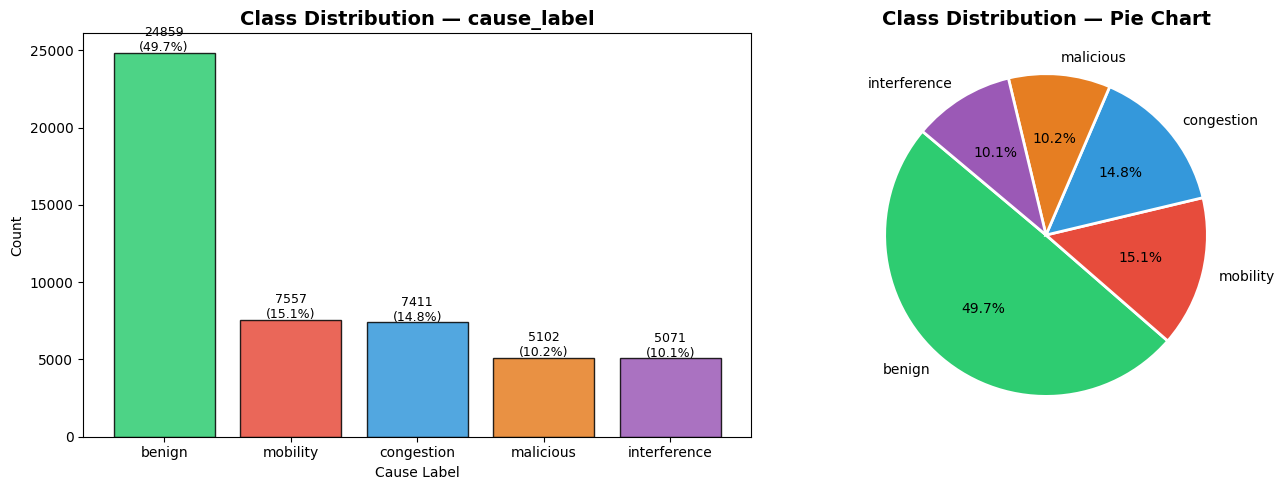

✅ Class Distribution plotted


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar plot
vc = df['cause_label'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22', '#9b59b6']
axes[0].bar(vc.index, vc.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution — cause_label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cause Label')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(vc.items()):
    axes[0].text(i, cnt + 100, f'{cnt}\n({cnt/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Class Distribution plotted')

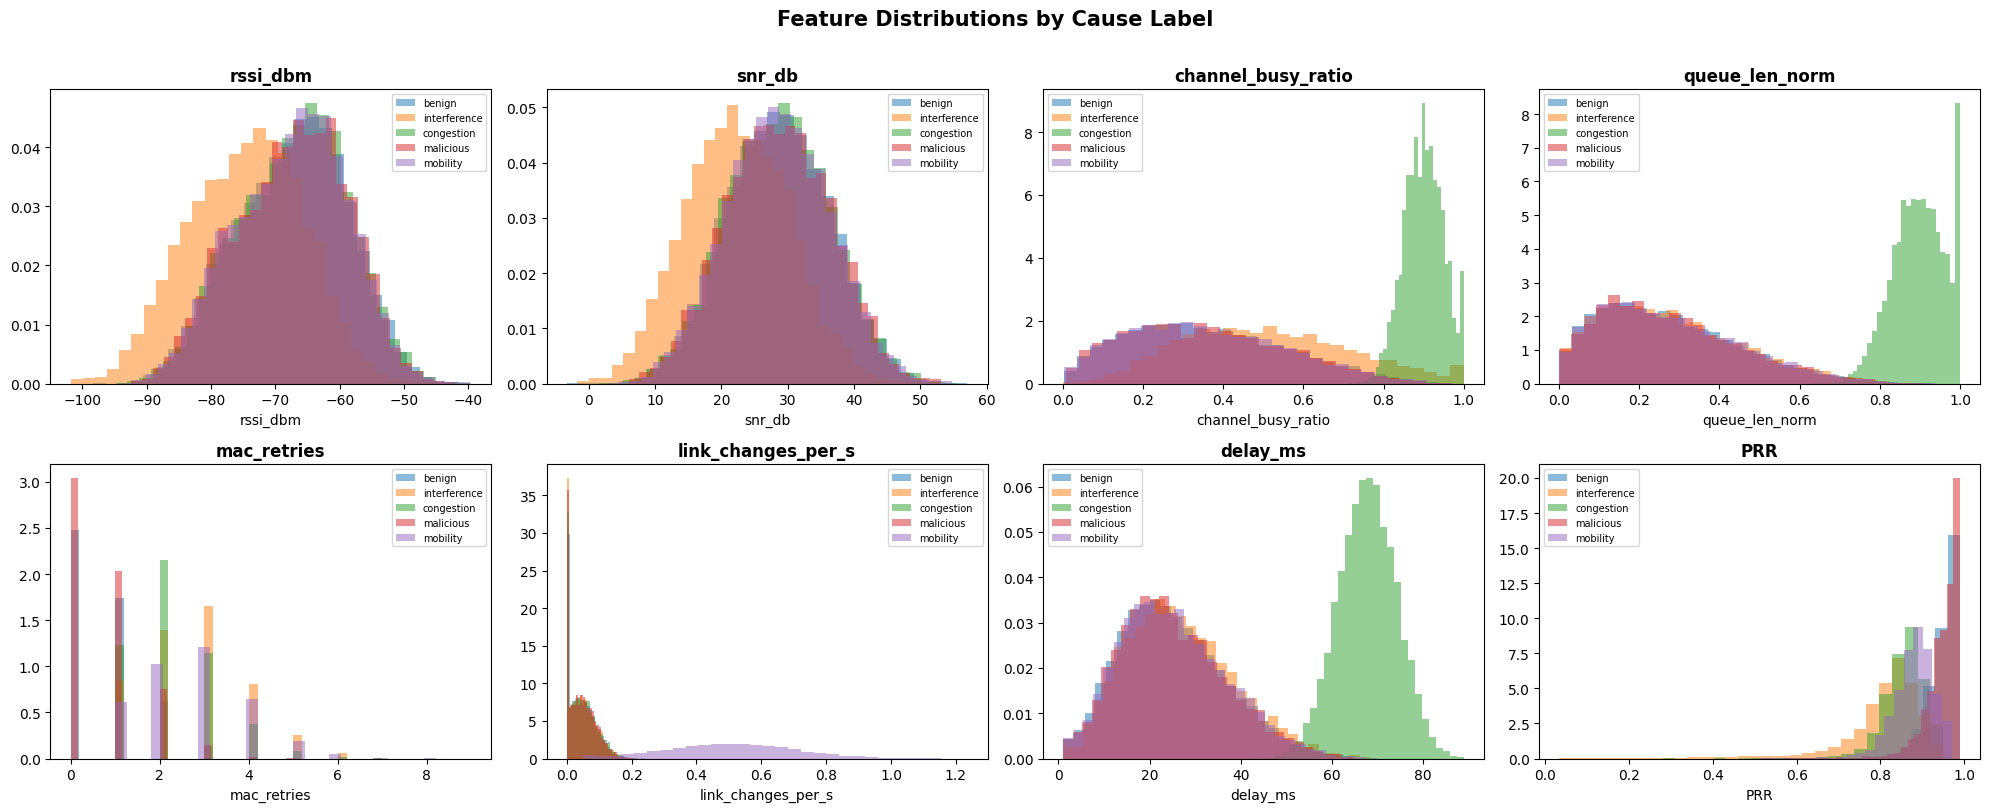

✅ Feature distributions plotted


In [ ]:
# Feature distributions by cause_label
key_features = ['rssi_dbm', 'snr_db', 'channel_busy_ratio', 'queue_len_norm',
                'mac_retries', 'link_changes_per_s', 'delay_ms', 'PRR']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label in df['cause_label'].unique():
        subset = df[df['cause_label'] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, density=True)
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Cause Label', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature distributions plotted')

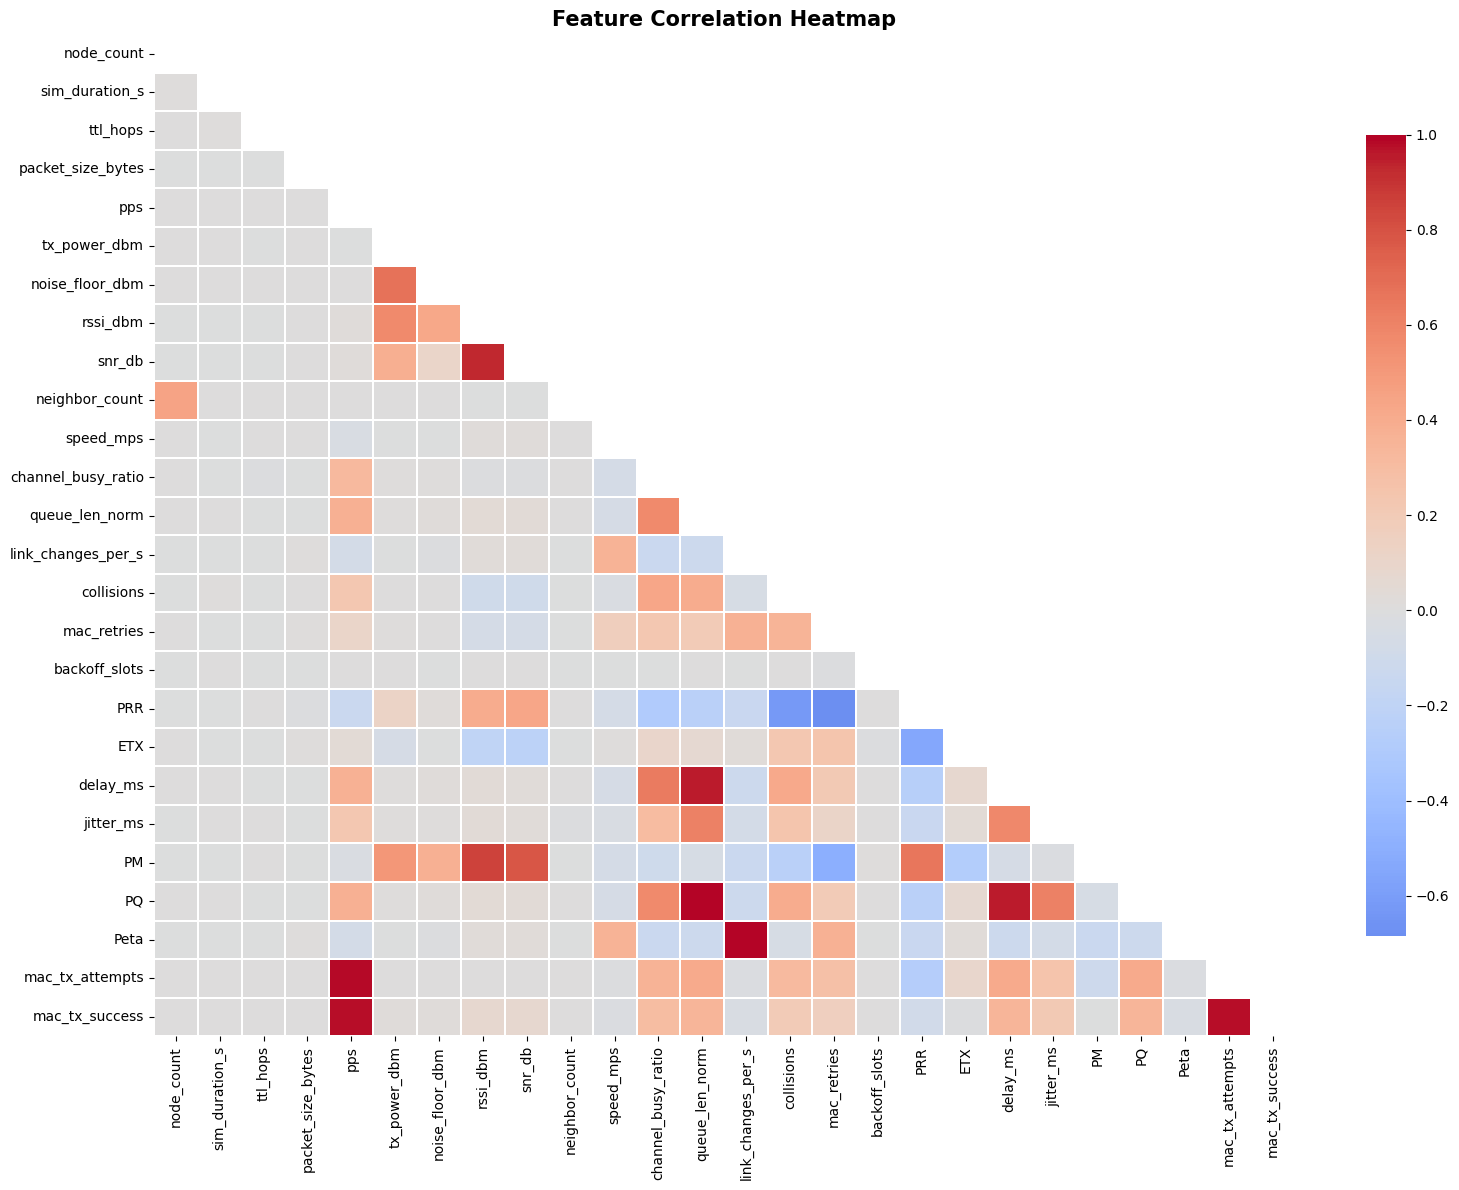

✅ Correlation heatmap plotted


In [ ]:
# Correlation heatmap of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove leakage and ID cols for correlation
exclude = ['run_id', 'ns3_seed', 'src_id', 'dst_id', 'flow_id',
           'rx_success', 'loss_occurred', 'queue_drops']
numeric_cols = [c for c in numeric_cols if c not in exclude]

plt.figure(figsize=(16, 12))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap plotted')

## 🔧 Step 4: Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── 4.1  Drop leakage + identifier columns ──────────────────────────────────
LEAKAGE_COLS = [
    'drop_reason',       # direct sub-label of cause_label
    'loss_occurred',     # derived from cause_label
    'rx_success',        # inverse of loss_occurred
    'queue_drops',       # reveals the drop event
]
ID_COLS = ['sim_label', 'run_id', 'ns3_seed', 'src_id', 'dst_id',
           'flow_id', 'timestamp']          # ← 'split' removed (column does not exist)

TARGET = 'cause_label'

df_model = df.drop(columns=LEAKAGE_COLS + ID_COLS)
print(f'Columns after dropping leakage & IDs: {df_model.shape[1]-1} features + 1 target')

# ── 4.2  Encode categorical features ────────────────────────────────────────
df_model['sim_area_m'] = df_model['sim_area_m'].str.replace('x', '*').apply(
    lambda x: eval(x) if isinstance(x, str) else x
)

CAT_COLS = ['mobility_model', 'channel_helper', 'stack', 'routing',
            'transport', 'app', 'phy']

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# ── 4.3  Encode target ───────────────────────────────────────────────────────
target_encoder = LabelEncoder()
df_model[TARGET] = target_encoder.fit_transform(df_model[TARGET])

CLASS_NAMES = target_encoder.classes_
print(f'\nClass encoding: {dict(zip(CLASS_NAMES, target_encoder.transform(CLASS_NAMES)))}')

# ── 4.4  Train / Test split (stratified 80/20, seed=42) ─────────────────────
FEATURE_COLS = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURE_COLS].values
y = df_model[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nX_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Features used ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Columns after dropping leakage & IDs: 34 features + 1 target

Class encoding: {'benign': np.int64(0), 'congestion': np.int64(1), 'interference': np.int64(2), 'malicious': np.int64(3), 'mobility': np.int64(4)}

X_train: (40000, 34), X_test: (10000, 34)
Features used (34): ['sim_area_m', 'node_count', 'sim_duration_s', 'mobility_model', 'channel_helper', 'stack', 'routing', 'transport', 'app', 'ttl_hops', 'packet_size_bytes', 'pps', 'phy', 'tx_power_dbm', 'noise_floor_dbm', 'rssi_dbm', 'snr_db', 'neighbor_count', 'speed_mps', 'channel_busy_ratio', 'queue_len_norm', 'link_changes_per_s', 'collisions', 'mac_retries', 'backoff_slots', 'PRR', 'ETX', 'delay_ms', 'jitter_ms', 'PM', 'PQ', 'Peta', 'mac_tx_attempts', 'mac_tx_success']


In [ ]:
# ── 4.5  Scale features (needed for TabNet; XGBoost doesn't need it) ─────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Preprocessing complete!')
print(f'  Training samples : {X_train.shape[0]}')
print(f'  Test samples     : {X_test.shape[0]}')
print(f'  Number of features: {X_train.shape[1]}')
print(f'  Number of classes : {len(CLASS_NAMES)}')
print(f'  Classes           : {CLASS_NAMES}')

✅ Preprocessing complete!
  Training samples : 40000
  Test samples     : 10000
  Number of features: 34
  Number of classes : 5
  Classes           : ['benign' 'congestion' 'interference' 'malicious' 'mobility']


## 🌲 Step 5: Model 1 — XGBoost (Baseline)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_sample_weight
import time

print('🌲 Training XGBoost ...')

# Compute sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0
)

start = time.time()
xgb_model.fit(
    X_train, y_train,
    sample_weight        = sample_weights,
    eval_set             = [(X_test, y_test)],
    verbose              = 100
)
xgb_time = time.time() - start

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb, average='macro')

print(f'\n✅ XGBoost Training complete in {xgb_time:.1f}s')
print(f'   Accuracy  : {xgb_acc*100:.2f}%')
print(f'   F1-Macro  : {xgb_f1*100:.2f}%')

🌲 Training XGBoost ...
[0]	validation_0-mlogloss:1.47343
[100]	validation_0-mlogloss:0.42239
[200]	validation_0-mlogloss:0.37162
[300]	validation_0-mlogloss:0.34425
[400]	validation_0-mlogloss:0.32855
[499]	validation_0-mlogloss:0.31705

✅ XGBoost Training complete in 18.0s
   Accuracy  : 89.88%
   F1-Macro  : 86.13%


In [ ]:
# XGBoost — detailed classification report
print('📊 XGBoost Classification Report:')
print('='*60)
print(classification_report(y_test, y_pred_xgb, target_names=CLASS_NAMES))

📊 XGBoost Classification Report:
              precision    recall  f1-score   support

      benign       0.88      0.94      0.91      4972
  congestion       1.00      1.00      1.00      1482
interference       0.82      0.90      0.86      1014
   malicious       0.75      0.45      0.56      1020
    mobility       0.99      0.97      0.98      1512

    accuracy                           0.90     10000
   macro avg       0.89      0.85      0.86     10000
weighted avg       0.89      0.90      0.89     10000



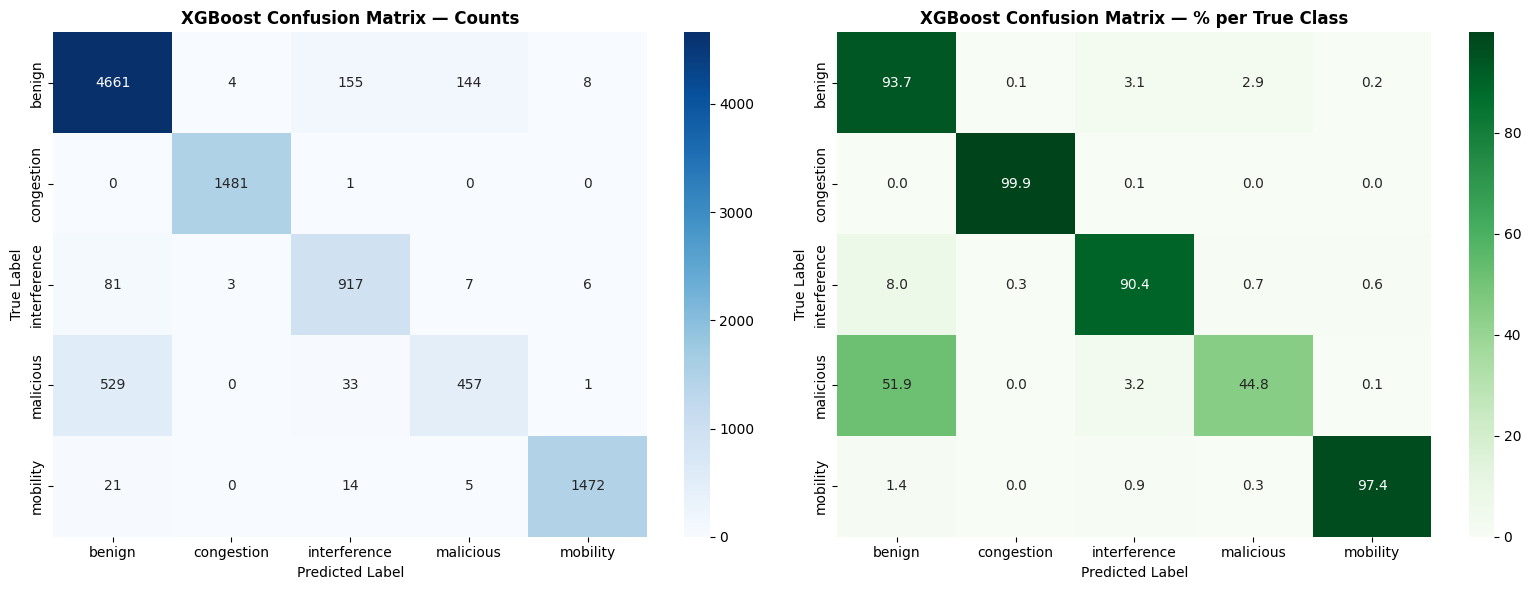

✅ XGBoost confusion matrix plotted


In [ ]:
# XGBoost Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{title} — Counts', fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # Percentages
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'{title} — % per True Class', fontweight='bold')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(y_test, y_pred_xgb, CLASS_NAMES,
                      'XGBoost Confusion Matrix', 'xgb_confusion_matrix.png')
print('✅ XGBoost confusion matrix plotted')

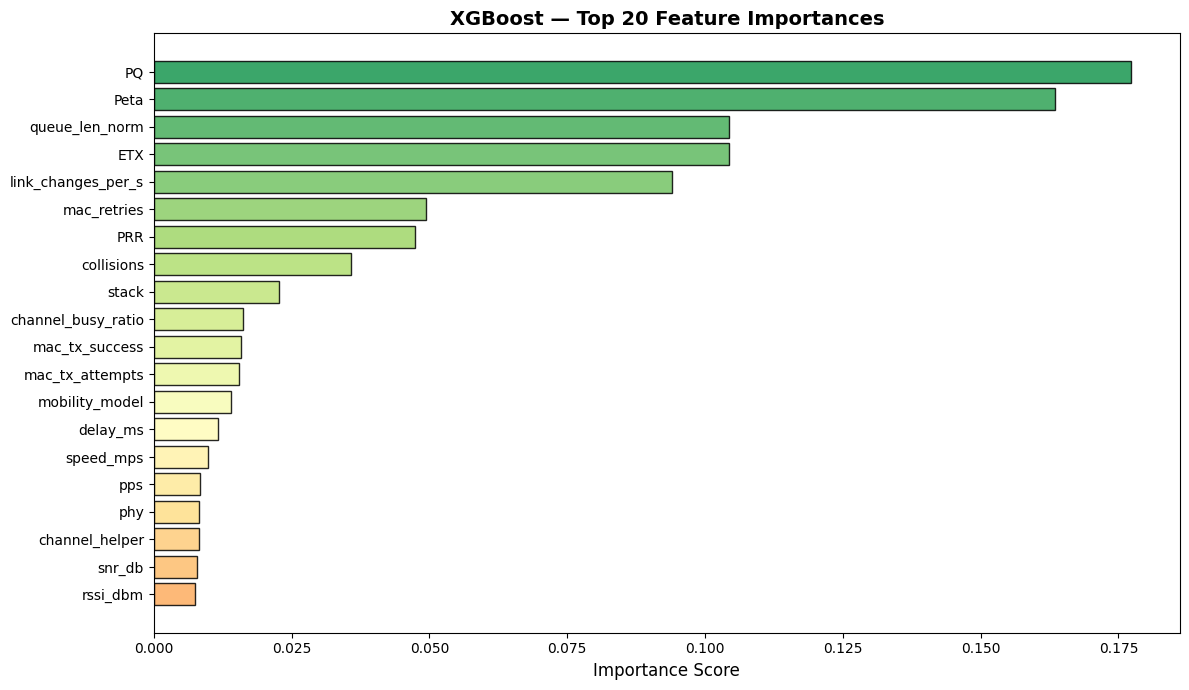

✅ XGBoost feature importance plotted


In [ ]:
# XGBoost Feature Importance
importances = xgb_model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12, 7))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp_df)))
bars = plt.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1],
                color=colors, edgecolor='black', alpha=0.85)
plt.xlabel('Importance Score', fontsize=12)
plt.title('XGBoost — Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ XGBoost feature importance plotted')

## 🧠 Step 6: Model 2 — TabNet (Deep Learning)

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

print(f'PyTorch version : {torch.__version__}')
print(f'GPU available   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device      : {torch.cuda.get_device_name(0)}')

print('\n🧠 Training TabNet ...')

# Class weights for imbalance handling
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))

tabnet_model = TabNetClassifier(
    n_d             = 32,       # Width of decision step
    n_a             = 32,       # Width of attention step
    n_steps         = 5,        # Number of sequential attention steps
    gamma           = 1.5,      # Coefficient for feature reuse
    n_independent   = 2,
    n_shared        = 2,
    momentum        = 0.02,
    epsilon         = 1e-15,
    seed            = 42,
    device_name     = 'auto',   # Uses GPU if available
    verbose         = 10
)

start = time.time()
tabnet_model.fit(
    X_train_scaled.astype(np.float32), y_train,
    eval_set        = [(X_test_scaled.astype(np.float32), y_test)],
    eval_name       = ['val'],
    eval_metric     = ['accuracy'],
    max_epochs      = 200,
    patience        = 20,       # Early stopping
    batch_size      = 1024,
    virtual_batch_size = 256,
    weights         = class_weight_dict,
    drop_last       = False
)
tabnet_time = time.time() - start

# Predictions
y_pred_tabnet = tabnet_model.predict(X_test_scaled.astype(np.float32))

tabnet_acc = accuracy_score(y_test, y_pred_tabnet)
tabnet_f1  = f1_score(y_test, y_pred_tabnet, average='macro')

print(f'\n✅ TabNet Training complete in {tabnet_time:.1f}s')
print(f'   Accuracy : {tabnet_acc*100:.2f}%')
print(f'   F1-Macro : {tabnet_f1*100:.2f}%')

In [ ]:
# TabNet training curves
plt.figure(figsize=(10, 4))
plt.plot(tabnet_model.history['val_accuracy'], label='Validation Accuracy', color='#3498db')
plt.plot(tabnet_model.history['loss'], label='Train Loss', color='#e74c3c', alpha=0.7)
plt.xlabel('Epoch')
plt.title('TabNet Training History', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tabnet_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ TabNet training history plotted')

In [ ]:
# TabNet detailed report
print('📊 TabNet Classification Report:')
print('='*60)
print(classification_report(y_test, y_pred_tabnet, target_names=CLASS_NAMES))

In [ ]:
# TabNet Confusion Matrix
plot_confusion_matrix(y_test, y_pred_tabnet, CLASS_NAMES,
                      'TabNet Confusion Matrix', 'tabnet_confusion_matrix.png')
print('✅ TabNet confusion matrix plotted')

In [ ]:
# TabNet Feature Importance (from attention mechanism)
tabnet_feat_imp = tabnet_model.feature_importances_
tabnet_imp_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': tabnet_feat_imp})
tabnet_imp_df = tabnet_imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12, 7))
colors = plt.cm.PuBuGn(np.linspace(0.3, 0.9, len(tabnet_imp_df)))
plt.barh(tabnet_imp_df['feature'][::-1], tabnet_imp_df['importance'][::-1],
         color=colors, edgecolor='black', alpha=0.85)
plt.xlabel('Attention Importance Score')
plt.title('TabNet — Top 20 Feature Importances (Attention Weights)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tabnet_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ TabNet feature importance plotted')

## 📊 Step 7: Model Comparison

In [ ]:
from sklearn.metrics import f1_score

# Per-class F1 scores
xgb_f1_per_class    = f1_score(y_test, y_pred_xgb,    average=None)
tabnet_f1_per_class = f1_score(y_test, y_pred_tabnet, average=None)

# Summary table
print('='*65)
print(f'{"Metric":<30} {"XGBoost":>15} {"TabNet":>15}')
print('='*65)
print(f'{"Accuracy":<30} {xgb_acc*100:>14.2f}% {tabnet_acc*100:>14.2f}%')
print(f'{"F1-Macro":<30} {xgb_f1*100:>14.2f}% {tabnet_f1*100:>14.2f}%')
print(f'{"Train Time (s)":<30} {xgb_time:>15.1f} {tabnet_time:>15.1f}')
print('-'*65)
for i, cls in enumerate(CLASS_NAMES):
    print(f'  F1 [{cls:<22}] {xgb_f1_per_class[i]*100:>14.2f}% {tabnet_f1_per_class[i]*100:>14.2f}%')
print('='*65)

NameError: name 'y_pred_tabnet' is not defined

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall metrics comparison
metrics = ['Accuracy', 'F1-Macro']
xgb_scores    = [xgb_acc*100, xgb_f1*100]
tabnet_scores = [tabnet_acc*100, tabnet_f1*100]

x = np.arange(len(metrics))
width = 0.35
axes[0].bar(x - width/2, xgb_scores,    width, label='XGBoost', color='#2ecc71', edgecolor='black')
axes[0].bar(x + width/2, tabnet_scores, width, label='TabNet',  color='#3498db', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(80, 100)
axes[0].set_title('Overall Performance Comparison', fontweight='bold')
axes[0].legend()
for i, (xs, ts) in enumerate(zip(xgb_scores, tabnet_scores)):
    axes[0].text(i - width/2, xs + 0.3, f'{xs:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i + width/2, ts + 0.3, f'{ts:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Per-class F1 comparison
x2 = np.arange(len(CLASS_NAMES))
axes[1].bar(x2 - width/2, xgb_f1_per_class*100,    width, label='XGBoost', color='#2ecc71', edgecolor='black')
axes[1].bar(x2 + width/2, tabnet_f1_per_class*100, width, label='TabNet',  color='#3498db', edgecolor='black')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(CLASS_NAMES, rotation=15)
axes[1].set_ylabel('F1 Score (%)')
axes[1].set_ylim(0, 105)
axes[1].set_title('Per-Class F1 Score Comparison', fontweight='bold')
axes[1].legend()

plt.suptitle('XGBoost vs TabNet — Full Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison plotted')

## 🔍 Step 8: SHAP Explainability (XGBoost)

In [ ]:
import shap
shap.initjs()

print('🔍 Computing SHAP values (this may take a minute)...')

# Use a sample for speed
X_test_df = pd.DataFrame(X_test, columns=FEATURE_COLS)
X_sample  = X_test_df.sample(1000, random_state=42)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print('✅ SHAP values computed!')

In [ ]:
# ── Handle both old (list) and new (3D array) SHAP API ──────────────────
# New SHAP (>=0.42): returns ndarray of shape (n_samples, n_features, n_classes)
# Old SHAP         : returns list of n_classes arrays each (n_samples, n_features)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # New API — shape: (n_samples, n_features, n_classes)
    shap_list = [shap_values[:, :, i] for i in range(len(CLASS_NAMES))]
    shap_for_bar = shap_values  # summary_plot accepts 3D directly for bar
else:
    # Old API — list of 2D arrays
    shap_list = shap_values
    shap_for_bar = shap_values

# SHAP Summary Plot — overall feature importance (bar)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_for_bar, X_sample,
    class_names=CLASS_NAMES,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — All Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP summary bar chart plotted')

In [ ]:
# SHAP Beeswarm plot per class — uses shap_list (compatible with old & new SHAP)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    plt.sca(axes[i])
    # shap_list[i] is always shape (n_samples, n_features) — safe for both APIs
    shap.summary_plot(
        shap_list[i], X_sample,
        max_display=10,
        show=False,
        plot_size=None
    )
    axes[i].set_title(f'SHAP — {cls}', fontweight='bold', fontsize=12)

# Hide unused subplot
axes[-1].axis('off')

plt.suptitle('SHAP Beeswarm Plots — Per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP per-class beeswarm plots done')

## 💾 Step 9: Save Models & Results

In [ ]:
import pickle, json

# Save XGBoost model
xgb_model.save_model('xgb_cause_label_model.json')
print('✅ XGBoost model saved → xgb_cause_label_model.json')

# Save TabNet model
tabnet_model.save_model('tabnet_cause_label_model')
print('✅ TabNet model saved  → tabnet_cause_label_model.zip')

# Save scaler and encoders
with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'scaler'          : scaler,
        'label_encoders'  : label_encoders,
        'target_encoder'  : target_encoder,
        'feature_cols'    : FEATURE_COLS,
        'class_names'     : list(CLASS_NAMES)
    }, f)
print('✅ Preprocessing artifacts saved → preprocessing_artifacts.pkl')

# Save results summary
results = {
    'XGBoost' : {'accuracy': round(xgb_acc, 4),    'f1_macro': round(xgb_f1, 4),
                 'per_class_f1': dict(zip(CLASS_NAMES, xgb_f1_per_class.round(4).tolist()))},
    'TabNet'  : {'accuracy': round(tabnet_acc, 4), 'f1_macro': round(tabnet_f1, 4),
                 'per_class_f1': dict(zip(CLASS_NAMES, tabnet_f1_per_class.round(4).tolist()))}
}
with open('results_summary.json', 'w') as f:
    json.dump(results, f, indent=2)
print('✅ Results saved       → results_summary.json')

## 🚀 Step 10: Inference — Predict on New Data

In [ ]:
def predict_cause(input_dict, model='xgboost'):
    """
    Predict the cause_label for a new network observation.

    Parameters:
    -----------
    input_dict : dict — feature name → value
    model      : 'xgboost' or 'tabnet'

    Returns:
    --------
    predicted class and probabilities
    """
    row = pd.DataFrame([input_dict])

    # Parse sim_area_m
    if 'sim_area_m' in row.columns and isinstance(row['sim_area_m'].iloc[0], str):
        row['sim_area_m'] = row['sim_area_m'].str.replace('x','*').apply(eval)

    # Encode categoricals
    for col, le in label_encoders.items():
        if col in row.columns:
            row[col] = le.transform(row[col].astype(str))

    # Reorder columns
    row = row[FEATURE_COLS].values

    if model == 'xgboost':
        pred_enc = xgb_model.predict(row)[0]
        proba    = xgb_model.predict_proba(row)[0]
    else:
        row_scaled = scaler.transform(row).astype(np.float32)
        pred_enc   = tabnet_model.predict(row_scaled)[0]
        proba      = tabnet_model.predict_proba(row_scaled)[0]

    pred_label = target_encoder.inverse_transform([pred_enc])[0]

    print(f'\n🔍 Prediction: {pred_label.upper()}')
    print('\nClass Probabilities:')
    for cls, p in sorted(zip(CLASS_NAMES, proba), key=lambda x: -x[1]):
        bar = '█' * int(p * 30)
        print(f'  {cls:<20}: {bar:<30} {p*100:.2f}%')
    return pred_label, proba


# ── Example prediction ─────────────────────────────────────────────────────
sample_input = dict(zip(FEATURE_COLS, X_test[0]))
# Convert encoded categoricals back for readability (optional)

print('Example inference using first test sample:')
print(f'True label: {target_encoder.inverse_transform([y_test[0]])[0]}')
predict_cause(pd.DataFrame(X_test[:1], columns=FEATURE_COLS).iloc[0].to_dict(), model='xgboost')

## 📋 Summary

| | XGBoost | TabNet |
|---|---|---|
| **Type** | Gradient Boosting | Deep Learning (Attention) |
| **Imbalance Handling** | `sample_weight='balanced'` | `weights=class_weight_dict` |
| **Scaling Needed** | ❌ No | ✅ Yes (StandardScaler) |
| **Interpretability** | SHAP values | Attention masks |
| **Best For** | Quick, reliable baseline | Capturing complex feature interactions |

### 🎯 Target Classes
| Class | Root Cause |
|---|---|
| `benign` | Normal/expected packet behavior |
| `congestion` | Queue overflow, buffer saturation |
| `mobility` | Link break, handoff timeout |
| `malicious` | Blackhole, greyhole, selective forward |
| `interference` | PHY errors, collision exceeded |

#new code

In [ ]:
!pip install imbalanced-learn xgboost scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

print("✅ All libraries loaded!")

✅ All libraries loaded!


#Cell 1 — Train All 4 Models

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
import time, warnings
warnings.filterwarnings('ignore')

results = {}

# ══════════════════════════════════════════════════════
# MODEL 1: XGBoost
# ══════════════════════════════════════════════════════
print("🌲 Training XGBoost...")
sw = compute_sample_weight('balanced', y=y_train)
xgb = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42,
    n_jobs=-1, verbosity=0
)
t0 = time.time()
xgb.fit(X_train, y_train, sample_weight=sw)
results['XGBoost'] = {
    'model': xgb, 'preds': xgb.predict(X_test),
    'time': time.time()-t0, 'color': '#2196F3'
}
print(f"  ✅ Done {results['XGBoost']['time']:.1f}s | F1-Macro: {f1_score(y_test, results['XGBoost']['preds'], average='macro')*100:.2f}%")

# ══════════════════════════════════════════════════════
# MODEL 2: Random Forest
# ══════════════════════════════════════════════════════
print("\n🌳 Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=500, max_depth=None,
    class_weight='balanced', random_state=42, n_jobs=-1
)
t0 = time.time()
rf.fit(X_train, y_train)
results['Random Forest'] = {
    'model': rf, 'preds': rf.predict(X_test),
    'time': time.time()-t0, 'color': '#4CAF50'
}
print(f"  ✅ Done {results['Random Forest']['time']:.1f}s | F1-Macro: {f1_score(y_test, results['Random Forest']['preds'], average='macro')*100:.2f}%")

# ══════════════════════════════════════════════════════
# MODEL 3: SVM
# ══════════════════════════════════════════════════════
print("\n🔷 Training SVM (uses scaled features)...")
from sklearn.svm import SVC
svm = SVC(
    kernel='rbf', C=10, gamma='scale',
    class_weight='balanced', probability=True,
    random_state=42
)
t0 = time.time()
# SVM needs scaled data — use X_train_scaled / X_test_scaled
svm.fit(X_train_scaled, y_train)
results['SVM'] = {
    'model': svm, 'preds': svm.predict(X_test_scaled),
    'time': time.time()-t0, 'color': '#FF9800'
}
print(f"  ✅ Done {results['SVM']['time']:.1f}s | F1-Macro: {f1_score(y_test, results['SVM']['preds'], average='macro')*100:.2f}%")

# ══════════════════════════════════════════════════════
# MODEL 4: MLP
# ══════════════════════════════════════════════════════
print("\n🧠 Training MLP...")
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu', solver='adam',
    learning_rate_init=0.001,
    max_iter=300, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=15,
    random_state=42
)
t0 = time.time()
mlp.fit(X_train_scaled, y_train)
results['MLP'] = {
    'model': mlp, 'preds': mlp.predict(X_test_scaled),
    'time': time.time()-t0, 'color': '#9C27B0'
}
print(f"  ✅ Done {results['MLP']['time']:.1f}s | F1-Macro: {f1_score(y_test, results['MLP']['preds'], average='macro')*100:.2f}%")

print("\n" + "="*60)
print("📊 SUMMARY")
print("="*60)
print(f"{'Model':<20} {'Accuracy':>10} {'F1-Macro':>10} {'Time(s)':>10}")
print("-"*60)
for name, r in results.items():
    acc = accuracy_score(y_test, r['preds'])
    f1  = f1_score(y_test, r['preds'], average='macro')
    print(f"{name:<20} {acc*100:>9.2f}% {f1*100:>9.2f}% {r['time']:>10.1f}")

🌲 Training XGBoost...
  ✅ Done 35.1s | F1-Macro: 86.13%

🌳 Training Random Forest...
  ✅ Done 65.2s | F1-Macro: 74.15%

🔷 Training SVM (uses scaled features)...
  ✅ Done 509.6s | F1-Macro: 82.41%

🧠 Training MLP...
  ✅ Done 22.0s | F1-Macro: 83.95%

📊 SUMMARY
Model                  Accuracy   F1-Macro    Time(s)
------------------------------------------------------------
XGBoost                  89.88%     86.13%       35.1
Random Forest            86.49%     74.15%       65.2
SVM                      85.03%     82.41%      509.6
MLP                      88.97%     83.95%       22.0


#Cell 2 — Classification Reports

In [ ]:
for name, r in results.items():
    print(f"\n{'='*60}")
    print(f"📊 {name} — Classification Report")
    print('='*60)
    print(classification_report(y_test, r['preds'], target_names=CLASS_NAMES))


📊 XGBoost — Classification Report
              precision    recall  f1-score   support

      benign       0.88      0.94      0.91      4972
  congestion       1.00      1.00      1.00      1482
interference       0.82      0.90      0.86      1014
   malicious       0.75      0.45      0.56      1020
    mobility       0.99      0.97      0.98      1512

    accuracy                           0.90     10000
   macro avg       0.89      0.85      0.86     10000
weighted avg       0.89      0.90      0.89     10000


📊 Random Forest — Classification Report
              precision    recall  f1-score   support

      benign       0.80      0.98      0.88      4972
  congestion       1.00      1.00      1.00      1482
interference       0.86      0.84      0.85      1014
   malicious       1.00      0.00      0.00      1020
    mobility       0.99      0.96      0.97      1512

    accuracy                           0.86     10000
   macro avg       0.93      0.76      0.74     10000
w

#Cell 3 — Confusion Matrices (2×2 Grid)

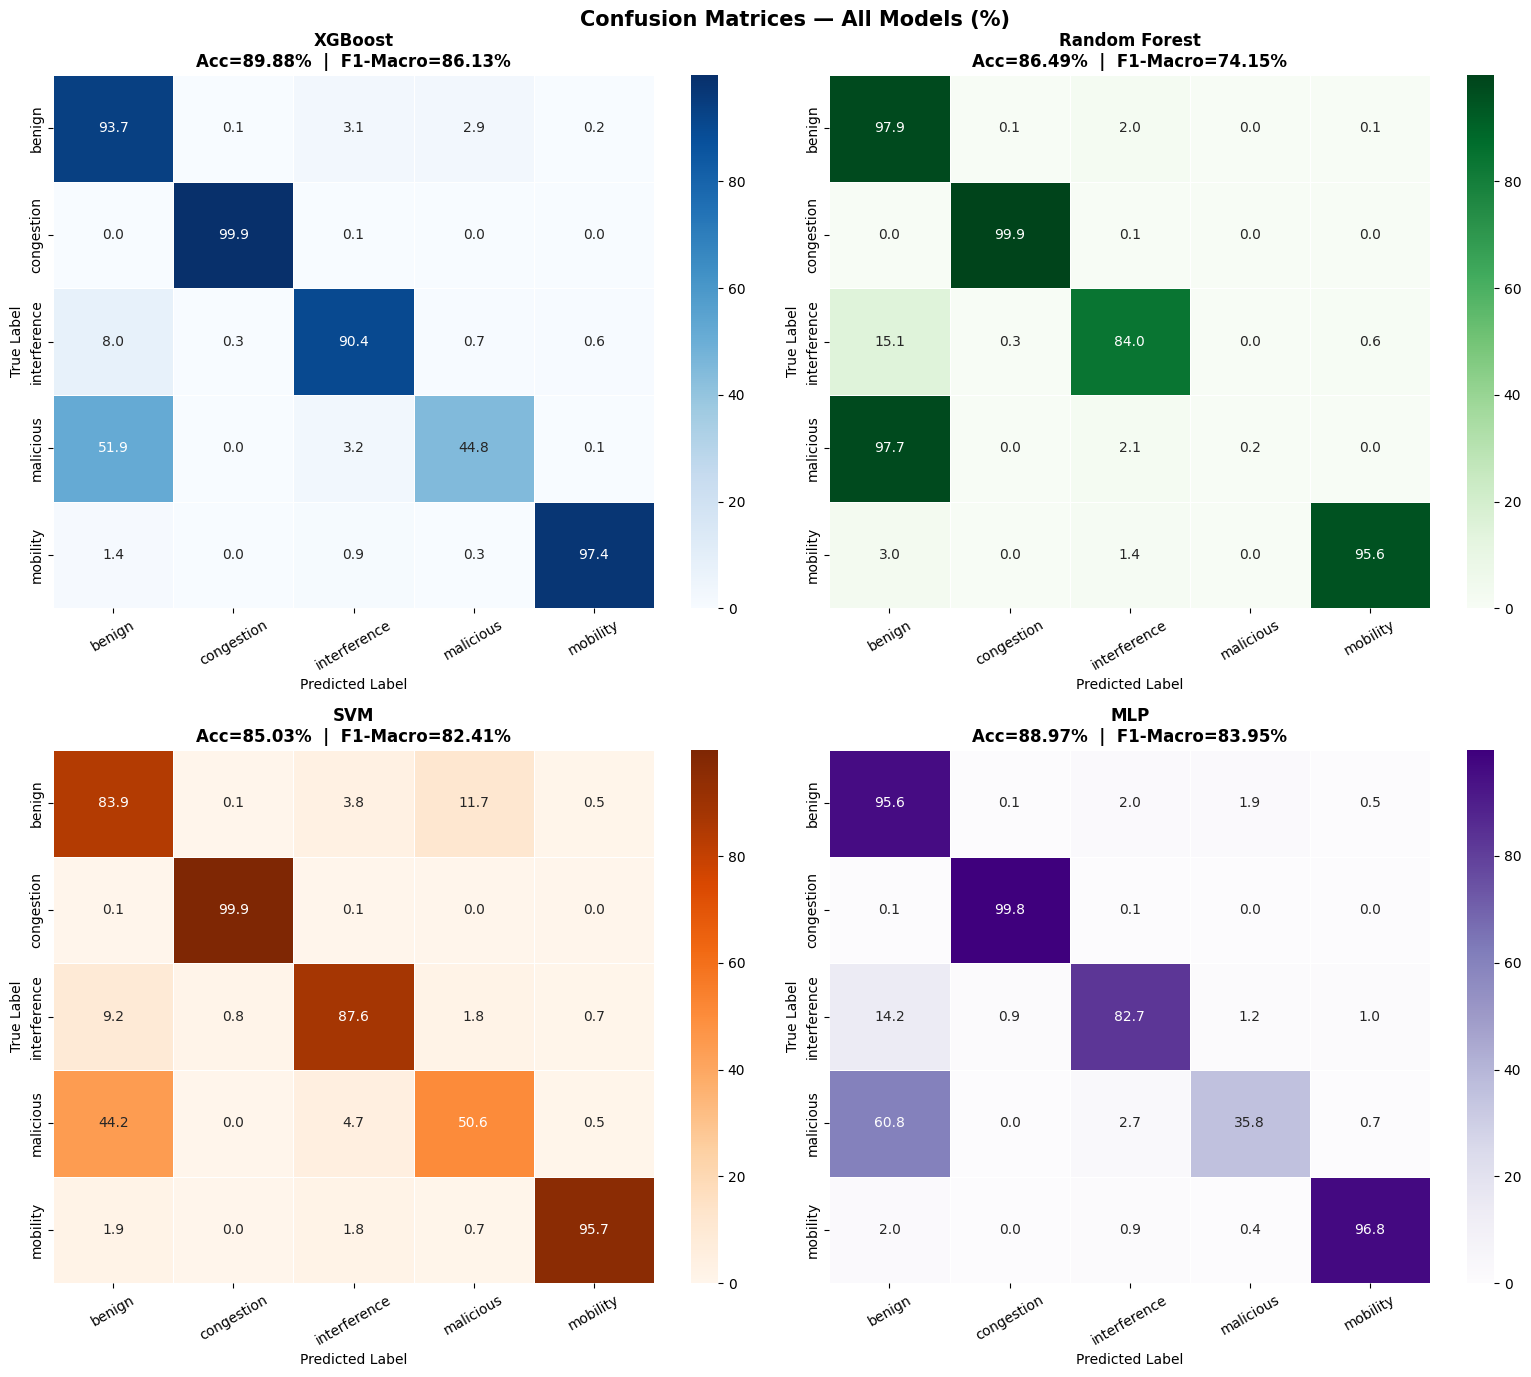

✅ Confusion matrices saved


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, (name, r), cmap in zip(axes, results.items(), cmaps):
    cm = confusion_matrix(y_test, r['preds'])
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    acc = accuracy_score(y_test, r['preds'])
    f1  = f1_score(y_test, r['preds'], average='macro')
    ax.set_title(f'{name}\nAcc={acc*100:.2f}%  |  F1-Macro={f1*100:.2f}%',
                 fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All Models (%)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig_Confusion_Matrices_All_Models.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved")

#Cell 4 — Per-Class F1 + Overall Metrics Comparison

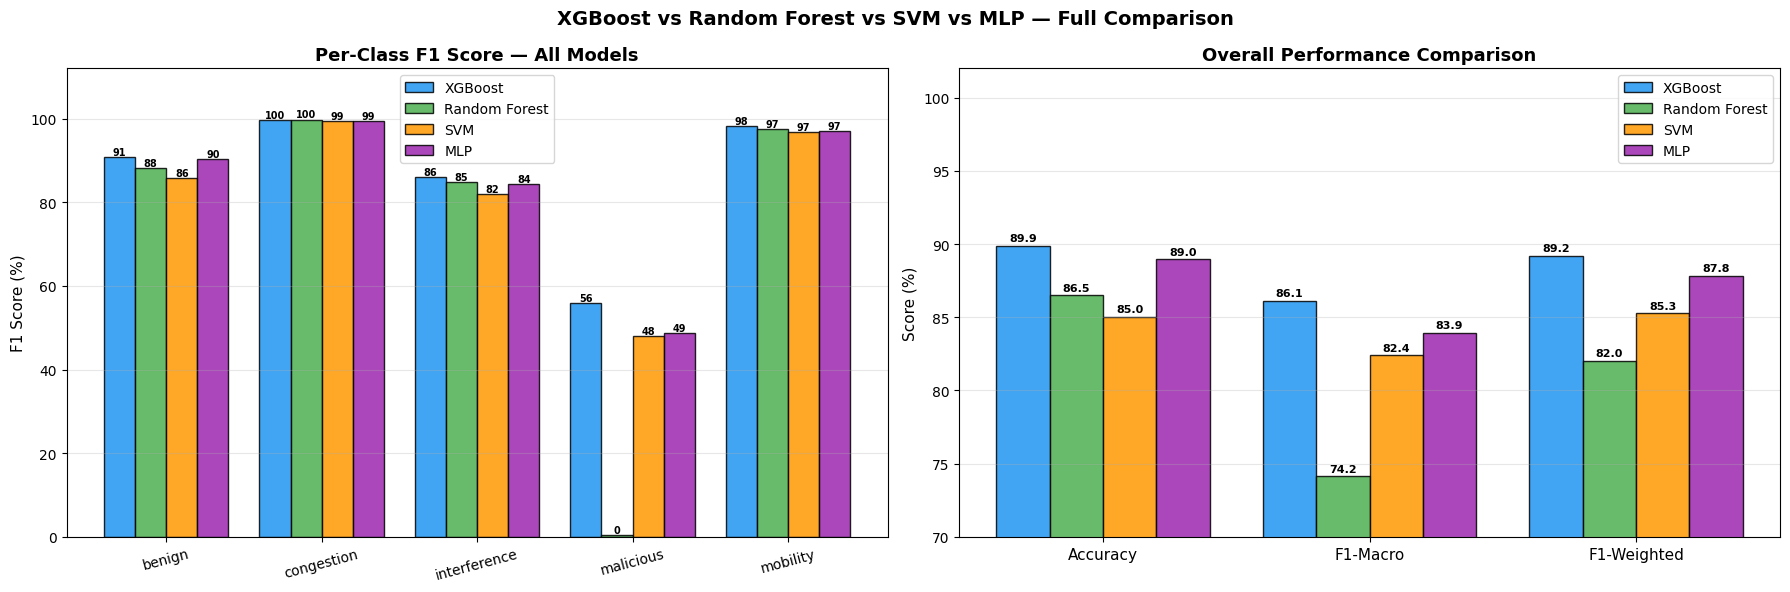

✅ Comparison figure saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
model_names = list(results.keys())
colors = [r['color'] for r in results.values()]
x = np.arange(len(CLASS_NAMES))
w = 0.2

# Per-class F1
for i, (name, r) in enumerate(results.items()):
    f1s = f1_score(y_test, r['preds'], average=None) * 100
    bars = axes[0].bar(x + i*w - 1.5*w, f1s, w,
                       label=name, color=r['color'], alpha=0.85, edgecolor='black')
    for xi, f in zip(x, f1s):
        axes[0].text(xi + i*w - 1.5*w, f + 0.5, f'{f:.0f}',
                     ha='center', fontsize=7, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES, rotation=15, fontsize=10)
axes[0].set_ylabel('F1 Score (%)', fontsize=11)
axes[0].set_ylim(0, 112)
axes[0].set_title('Per-Class F1 Score — All Models', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Overall metrics grouped bar
metric_labels = ['Accuracy', 'F1-Macro', 'F1-Weighted']
xm = np.arange(len(metric_labels))
wm = 0.2
for i, (name, r) in enumerate(results.items()):
    vals = [
        accuracy_score(y_test, r['preds'])*100,
        f1_score(y_test, r['preds'], average='macro')*100,
        f1_score(y_test, r['preds'], average='weighted')*100,
    ]
    bars = axes[1].bar(xm + i*wm - 1.5*wm, vals, wm,
                       label=name, color=r['color'], alpha=0.85, edgecolor='black')
    for xi, v in zip(xm, vals):
        axes[1].text(xi + i*wm - 1.5*wm, v + 0.3, f'{v:.1f}',
                     ha='center', fontsize=8, fontweight='bold')

axes[1].set_xticks(xm)
axes[1].set_xticklabels(metric_labels, fontsize=11)
axes[1].set_ylabel('Score (%)', fontsize=11)
axes[1].set_ylim(70, 102)
axes[1].set_title('Overall Performance Comparison', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('XGBoost vs Random Forest vs SVM vs MLP — Full Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig_Model_Comparison_All.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Comparison figure saved")

#Cell 5 — Malicious Class Focus (Key Security Figure)

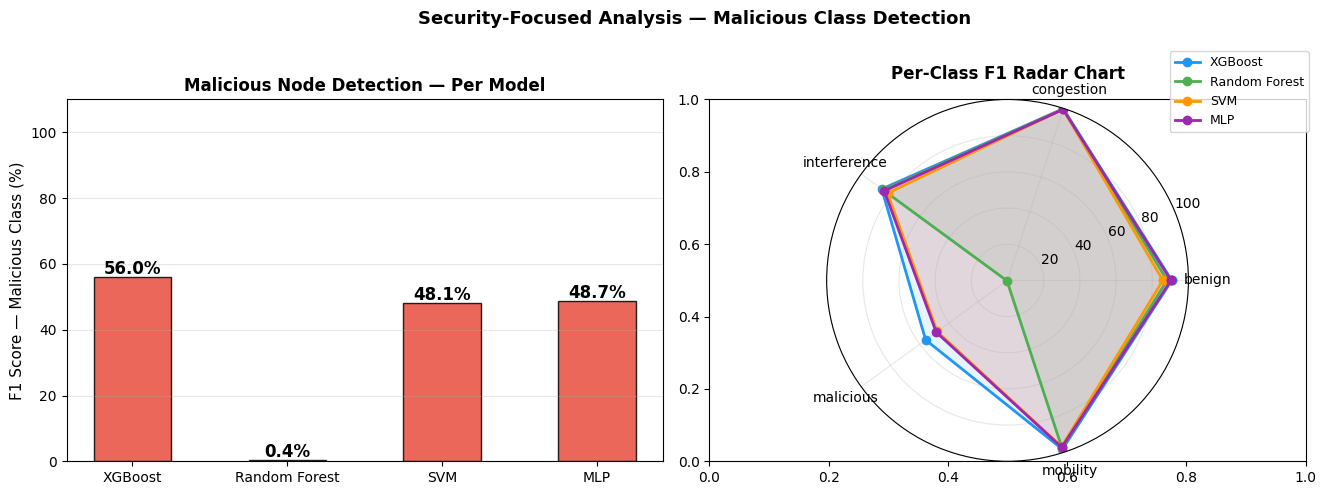

✅ Malicious detection figure saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Malicious F1 per model
mal_idx = list(CLASS_NAMES).index('malicious')
mal_f1s = [f1_score(y_test, r['preds'], average=None)[mal_idx]*100
           for r in results.values()]
bar_colors = ['#e74c3c' if v < 60 else '#f39c12' if v < 80 else '#2ecc71'
              for v in mal_f1s]
bars = axes[0].bar(model_names, mal_f1s, color=bar_colors,
                   edgecolor='black', alpha=0.85, width=0.5)
for bar, val in zip(bars, mal_f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('F1 Score — Malicious Class (%)', fontsize=11)
axes[0].set_title('Malicious Node Detection — Per Model', fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].grid(axis='y', alpha=0.3)

# Radar / spider chart for all classes
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

categories = list(CLASS_NAMES)
N = len(categories)
angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

ax_radar = plt.subplot(122, polar=True)
for name, r in results.items():
    f1s = list(f1_score(y_test, r['preds'], average=None)*100)
    f1s += f1s[:1]
    ax_radar.plot(angles, f1s, 'o-', linewidth=2, label=name, color=r['color'])
    ax_radar.fill(angles, f1s, alpha=0.1, color=r['color'])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, size=10)
ax_radar.set_ylim(0, 100)
ax_radar.set_title('Per-Class F1 Radar Chart', fontweight='bold',
                   pad=15, fontsize=12)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax_radar.grid(True, alpha=0.3)

plt.suptitle('Security-Focused Analysis — Malicious Class Detection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig_Malicious_Detection_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Malicious detection figure saved")

#Cell 6 — Feature Importance (XGBoost + RF Side by Side)

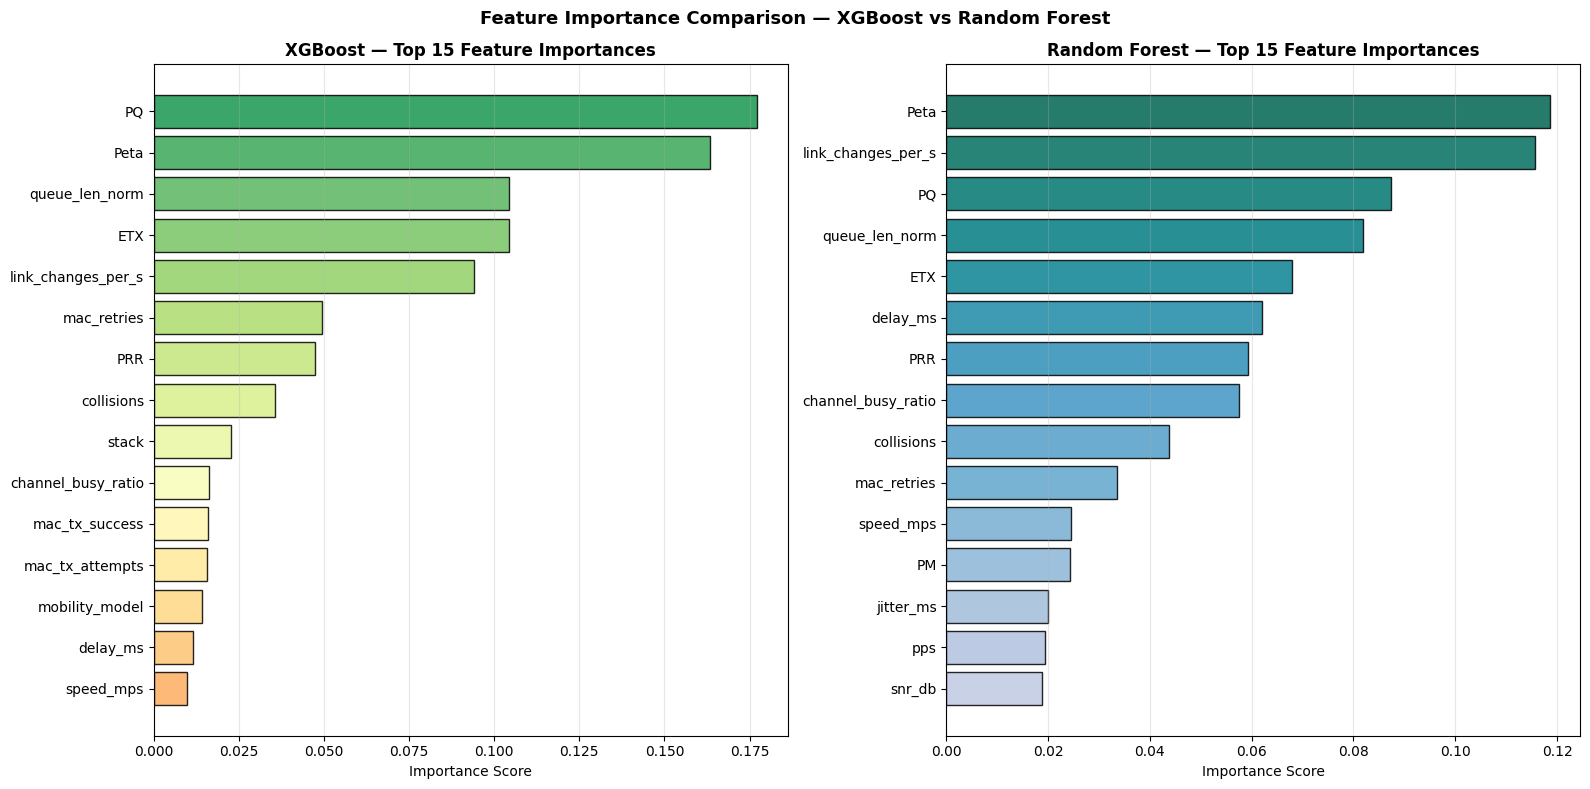

✅ Feature importance figure saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# XGBoost importance
xgb_imp = pd.DataFrame({'feature': FEATURE_COLS,
                         'importance': xgb.feature_importances_})\
            .sort_values('importance', ascending=False).head(15)
colors_xgb = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15))
axes[0].barh(xgb_imp['feature'][::-1], xgb_imp['importance'][::-1],
             color=colors_xgb, edgecolor='black', alpha=0.85)
axes[0].set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', alpha=0.3)

# RF importance
rf_imp = pd.DataFrame({'feature': FEATURE_COLS,
                        'importance': rf.feature_importances_})\
           .sort_values('importance', ascending=False).head(15)
colors_rf = plt.cm.PuBuGn(np.linspace(0.3, 0.9, 15))
axes[1].barh(rf_imp['feature'][::-1], rf_imp['importance'][::-1],
             color=colors_rf, edgecolor='black', alpha=0.85)
axes[1].set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Comparison — XGBoost vs Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig_Feature_Importance_XGB_RF.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Feature importance figure saved")

#EXPORT: predictions + probabilities for McNemar & AUC analysis

In [ ]:
# ── EXPORT: predictions + probabilities for McNemar & AUC analysis ──────────
import pandas as pd
import numpy as np

mal_idx = list(CLASS_NAMES).index('malicious')

predictions_df = pd.DataFrame({
    'true_label'          : y_test,
    'xgb_pred'            : results['XGBoost']['preds'],
    'rf_pred'             : results['Random Forest']['preds'],
    'svm_pred'            : results['SVM']['preds'],
    'mlp_pred'            : results['MLP']['preds'],
    'xgb_proba_malicious' : results['XGBoost']['model'].predict_proba(X_test)[:, mal_idx],
    'rf_proba_malicious'  : results['Random Forest']['model'].predict_proba(X_test)[:, mal_idx],
    'svm_proba_malicious' : results['SVM']['model'].predict_proba(X_test_scaled)[:, mal_idx],
    'mlp_proba_malicious' : results['MLP']['model'].predict_proba(X_test_scaled)[:, mal_idx],
})

predictions_df.to_csv('model_predictions.csv', index=False)
print(f'Saved {len(predictions_df)} rows')
print(predictions_df.head())
print(f'\nClass names: {CLASS_NAMES}')
print(f'Malicious class index: {mal_idx}')

Saved 10000 rows
   true_label  xgb_pred  rf_pred  svm_pred  mlp_pred  xgb_proba_malicious  \
0           0         0        0         0         0             0.166279   
1           0         0        0         0         0             0.417811   
2           0         0        0         0         0             0.084789   
3           0         0        0         0         0             0.198350   
4           0         0        0         3         0             0.222659   

   rf_proba_malicious  svm_proba_malicious  mlp_proba_malicious  
0               0.124             0.144112             0.128982  
1               0.170             0.097753             0.086149  
2               0.176             0.029516             0.020058  
3               0.148             0.112767             0.125843  
4               0.152             0.257479             0.129108  

Class names: ['benign' 'congestion' 'interference' 'malicious' 'mobility']
Malicious class index: 3


#Cell 7 — Save All Results & Download ZIP

In [ ]:
import shutil, os, json
from google.colab import files

os.makedirs('/content/ML_FGA_v3', exist_ok=True)

# Save all figures
figs = [
    'Fig_Confusion_Matrices_All_Models.png',
    'Fig_Model_Comparison_All.png',
    'Fig_Malicious_Detection_Analysis.png',
    'Fig_Feature_Importance_XGB_RF.png',
    'shap_summary_bar.png',
    'shap_beeswarm_per_class.png',
    'class_distribution.png',
    'feature_distributions.png',
    'correlation_heatmap.png',
]
for f in figs:
    if os.path.exists(f'/content/{f}'):
        shutil.copy2(f'/content/{f}', f'/content/ML_FGA_v3/{f}')

# Save summary CSV
rows = []
for name, r in results.items():
    f1_per = f1_score(y_test, r['preds'], average=None)
    rows.append({
        'Model'          : name,
        'Accuracy'       : round(accuracy_score(y_test, r['preds']), 4),
        'F1_Macro'       : round(f1_score(y_test, r['preds'], average='macro'), 4),
        'F1_Weighted'    : round(f1_score(y_test, r['preds'], average='weighted'), 4),
        'Train_Time_s'   : round(r['time'], 2),
        'F1_benign'      : round(f1_per[list(CLASS_NAMES).index('benign')], 4),
        'F1_congestion'  : round(f1_per[list(CLASS_NAMES).index('congestion')], 4),
        'F1_mobility'    : round(f1_per[list(CLASS_NAMES).index('mobility')], 4),
        'F1_interference': round(f1_per[list(CLASS_NAMES).index('interference')], 4),
        'F1_malicious'   : round(f1_per[list(CLASS_NAMES).index('malicious')], 4),
    })

pd.DataFrame(rows).to_csv('/content/ML_FGA_v3/Table_All_Models_Summary.csv', index=False)

# Save classification reports
for name, r in results.items():
    fname = name.replace(' ', '_')
    with open(f'/content/ML_FGA_v3/Report_{fname}.txt', 'w') as f:
        f.write(f"{name} — Classification Report\n{'='*60}\n")
        f.write(classification_report(y_test, r['preds'], target_names=CLASS_NAMES))

    cm = pd.DataFrame(confusion_matrix(y_test, r['preds']),
                      index=CLASS_NAMES, columns=CLASS_NAMES)
    cm.to_csv(f'/content/ML_FGA_v3/CM_{fname}.csv')

# ZIP and download
shutil.make_archive('/content/ML_FGA_v3', 'zip', '/content/ML_FGA_v3')
files.download('/content/ML_FGA_v3.zip')
print("✅ Downloaded ML_FGA_v3.zip — ready for paper!")

#code after round 3


In [ ]:
import pickle
import os

# Load the saved model
XGB_PATH = '/content/drive/MyDrive/ML-FGA paper/mlfga_iot_xgb_model.pkl'
if not os.path.exists(XGB_PATH):
    XGB_PATH = '/content/mlfga_iot_xgb_model.pkl'

with open(XGB_PATH, 'rb') as f:
    xgb_orig = pickle.load(f)

# Check what the model expects
print("=== Saved Model Info ===")
print(f"Model type: {type(xgb_orig)}")
print(f"Features model was trained on: {xgb_orig.n_features_in_}")

# Check what your current data has
print(f"\n=== Current Data ===")
print(f"X_train features: {X_train.shape[1]}")
print(f"X_test features:  {X_test.shape[1]}")
print(f"FEATURE_COLS count: {len(FEATURE_COLS)}")

# Show which features are in current data
print(f"\n=== Current FEATURE_COLS ===")
for i, f in enumerate(FEATURE_COLS):
    print(f"  {i:2d}: {f}")

=== Saved Model Info ===
Model type: <class 'xgboost.sklearn.XGBClassifier'>
Features model was trained on: 39

=== Current Data ===
X_train features: 34
X_test features:  34
FEATURE_COLS count: 34

=== Current FEATURE_COLS ===
   0: sim_area_m
   1: node_count
   2: sim_duration_s
   3: mobility_model
   4: channel_helper
   5: stack
   6: routing
   7: transport
   8: app
   9: ttl_hops
  10: packet_size_bytes
  11: pps
  12: phy
  13: tx_power_dbm
  14: noise_floor_dbm
  15: rssi_dbm
  16: snr_db
  17: neighbor_count
  18: speed_mps
  19: channel_busy_ratio
  20: queue_len_norm
  21: link_changes_per_s
  22: collisions
  23: mac_retries
  24: backoff_slots
  25: PRR
  26: ETX
  27: delay_ms
  28: jitter_ms
  29: PM
  30: PQ
  31: Peta
  32: mac_tx_attempts
  33: mac_tx_success


In [ ]:
# Retrain XGBoost on current 34-feature NS3 dataset
# Takes ~2-3 minutes

from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

print(f"Training XGBoost on {X_train.shape[1]} features...")
print(f"Train size: {X_train.shape[0]} records")

sw = compute_sample_weight('balanced', y_train)

xgb_orig = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False)

xgb_orig.fit(X_train, y_train, sample_weight=sw)

# Check baseline matches paper
y_pred_orig = xgb_orig.predict(X_test)
orig_acc    = accuracy_score(y_test, y_pred_orig)
orig_mac    = f1_score(y_test, y_pred_orig, average='macro')
orig_mal    = f1_score(y_test, y_pred_orig, average=None)[mal_idx]

print(f"\n=== Baseline Results vs Paper ===")
print(f"{'Metric':<20} {'Got':>8} {'Paper':>8} {'Match':>8}")
print("-"*46)
print(f"{'Accuracy':<20} {orig_acc*100:>7.2f}% {89.20:>7.2f}% "
      f"{'✓' if abs(orig_acc*100-89.20)<1 else '✗'}")
print(f"{'F1-Macro':<20} {orig_mac*100:>7.2f}% {85.41:>7.2f}% "
      f"{'✓' if abs(orig_mac*100-85.41)<1 else '✗'}")
print(f"{'Malicious F1':<20} {orig_mal*100:>7.2f}% {53.94:>7.2f}% "
      f"{'✓' if abs(orig_mal*100-53.94)<2 else '✗'}")

print(f"\n=== Full Report ===")
print(classification_report(
    y_test, y_pred_orig,
    target_names=le_target.classes_))

Training XGBoost on 34 features...
Train size: 40000 records

=== Baseline Results vs Paper ===
Metric                    Got    Paper    Match
----------------------------------------------
Accuracy               89.88%   89.20% ✓
F1-Macro               86.13%   85.41% ✓
Malicious F1           55.97%   53.94% ✗

=== Full Report ===
              precision    recall  f1-score   support

      benign       0.88      0.94      0.91      4972
  congestion       1.00      1.00      1.00      1482
interference       0.82      0.90      0.86      1014
   malicious       0.75      0.45      0.56      1020
    mobility       0.99      0.97      0.98      1512

    accuracy                           0.90     10000
   macro avg       0.89      0.85      0.86     10000
weighted avg       0.89      0.90      0.89     10000



In [ ]:
from imblearn.over_sampling import SMOTE
print("="*50)
print("EXPERIMENT 1: SMOTE + XGBoost")
print("="*50)

# Apply SMOTE to training set only
smote = SMOTE(random_state=42, k_neighbors=5)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

print("Class distribution:")
print(f"Before SMOTE:")
for cls, cnt in zip(le_target.classes_,
                    np.bincount(y_train)):
    print(f"  {cls:<15}: {cnt}")

print(f"\nAfter SMOTE:")
for cls, cnt in zip(le_target.classes_,
                    np.bincount(y_sm)):
    print(f"  {cls:<15}: {cnt}")

# Train XGBoost on SMOTE data
print("\nTraining XGBoost on SMOTE data...")
xgb_smote = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False)

xgb_smote.fit(X_sm, y_sm)
y_pred_smote = xgb_smote.predict(X_test)

smote_acc = accuracy_score(y_test, y_pred_smote)
smote_mac = f1_score(y_test, y_pred_smote,
                     average='macro')
smote_mal = f1_score(y_test, y_pred_smote,
                     average=None)[mal_idx]

print(f"\n=== Full Classification Report ===")
print(classification_report(
    y_test, y_pred_smote,
    target_names=le_target.classes_))

print(f"\n=== COMPARISON: Baseline vs SMOTE ===")
print(f"{'Metric':<20} {'Baseline':>10} "
      f"{'SMOTE':>10} {'Change':>10}")
print("-"*52)
for name, orig, new in [
    ("Accuracy",     orig_acc, smote_acc),
    ("F1-Macro",     orig_mac, smote_mac),
    ("Malicious F1", orig_mal, smote_mal),
]:
    change = (new - orig)*100
    sign   = "+" if change >= 0 else ""
    print(f"{name:<20} {orig*100:>9.2f}% "
          f"{new*100:>9.2f}% "
          f"{sign}{change:>8.2f}%")

EXPERIMENT 1: SMOTE + XGBoost
Class distribution:
Before SMOTE:
  benign         : 19887
  congestion     : 5929
  interference   : 4057
  malicious      : 4082
  mobility       : 6045

After SMOTE:
  benign         : 19887
  congestion     : 19887
  interference   : 19887
  malicious      : 19887
  mobility       : 19887

Training XGBoost on SMOTE data...

=== Full Classification Report ===
              precision    recall  f1-score   support

      benign       0.86      0.97      0.92      4972
  congestion       1.00      1.00      1.00      1482
interference       0.87      0.87      0.87      1014
   malicious       0.92      0.37      0.53      1020
    mobility       0.99      0.97      0.98      1512

    accuracy                           0.91     10000
   macro avg       0.93      0.84      0.86     10000
weighted avg       0.91      0.91      0.89     10000


=== COMPARISON: Baseline vs SMOTE ===
Metric                 Baseline      SMOTE     Change
-----------------------

In [ ]:
print("="*50)
print("EXPERIMENT 1b: Cost-Sensitive XGBoost")
print("(No SMOTE — use scale_pos_weight instead)")
print("="*50)

# Calculate optimal weight for malicious class
n_total   = len(y_train)
n_mal     = np.sum(y_train == mal_idx)
n_non_mal = n_total - n_mal
spw       = n_non_mal / n_mal

print(f"Malicious samples:     {n_mal}")
print(f"Non-malicious samples: {n_non_mal}")
print(f"scale_pos_weight:      {spw:.2f}")

# Try multiple weight multipliers
results_cost = []

for multiplier in [1.0, 2.0, 3.0, 4.0, 5.0]:
    weight = spw * multiplier

    sw_cost = np.where(y_train == mal_idx,
                       weight, 1.0)

    xgb_cost = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False)

    xgb_cost.fit(X_train, y_train,
                 sample_weight=sw_cost)

    y_pr     = xgb_cost.predict(X_test)
    acc      = accuracy_score(y_test, y_pr)
    mac      = f1_score(y_test, y_pr, average='macro')
    mal      = f1_score(y_test, y_pr, average=None)[mal_idx]
    mal_rec  = f1_score(y_test, y_pr,
                        average=None,
                        labels=[mal_idx])[0]

    results_cost.append({
        'multiplier': multiplier,
        'weight':     weight,
        'acc':        acc,
        'mac':        mac,
        'mal_f1':     mal,
        'model':      xgb_cost,
        'y_pred':     y_pr
    })

    print(f"  weight={weight:5.1f}x  "
          f"Acc={acc*100:.2f}%  "
          f"F1-Mac={mac*100:.2f}%  "
          f"Mal-F1={mal*100:.2f}%")

# Find best by malicious F1
best = max(results_cost, key=lambda x: x['mal_f1'])
print(f"\n✓ Best multiplier: {best['multiplier']}x "
      f"(weight={best['weight']:.1f})")

print(f"\n=== Full Report — Best Cost-Sensitive XGBoost ===")
print(classification_report(
    y_test, best['y_pred'],
    target_names=le_target.classes_))

print(f"\n=== FINAL COMPARISON TABLE ===")
print(f"{'Metric':<20} {'Baseline':>10} "
      f"{'SMOTE':>10} {'Cost-Sensitive':>15}")
print("-"*57)
for name, orig, sm, cs in [
    ("Accuracy",
     orig_acc,  smote_acc,  best['acc']),
    ("F1-Macro",
     orig_mac,  smote_mac,  best['mac']),
    ("Malicious F1",
     orig_mal,  smote_mal,  best['mal_f1']),
]:
    print(f"{name:<20} {orig*100:>9.2f}% "
          f"{sm*100:>9.2f}% "
          f"{cs*100:>14.2f}%")

# Save best model and predictions for later
xgb_best       = best['model']
y_pred_best    = best['y_pred']
best_mal_f1    = best['mal_f1']
best_acc       = best['acc']
best_mac       = best['mac']
best_weight    = best['weight']
best_mult      = best['multiplier']

EXPERIMENT 1b: Cost-Sensitive XGBoost
(No SMOTE — use scale_pos_weight instead)
Malicious samples:     4082
Non-malicious samples: 35918
scale_pos_weight:      8.80
  weight=  8.8x  Acc=88.22%  F1-Mac=85.21%  Mal-F1=52.45%
  weight= 17.6x  Acc=83.21%  F1-Mac=82.46%  Mal-F1=44.58%
  weight= 26.4x  Acc=80.24%  F1-Mac=81.13%  Mal-F1=41.91%
  weight= 35.2x  Acc=77.51%  F1-Mac=79.81%  Mal-F1=39.00%
  weight= 44.0x  Acc=75.90%  F1-Mac=79.13%  Mal-F1=38.10%

✓ Best multiplier: 1.0x (weight=8.8)

=== Full Report — Best Cost-Sensitive XGBoost ===
              precision    recall  f1-score   support

      benign       0.88      0.90      0.89      4972
  congestion       1.00      1.00      1.00      1482
interference       0.88      0.86      0.87      1014
   malicious       0.56      0.49      0.52      1020
    mobility       0.99      0.97      0.98      1512

    accuracy                           0.88     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.8

In [ ]:
print("="*50)
print("EXPERIMENT 2: 5-Fold Stratified CV")
print("="*50)

X_full = np.vstack([X_train, X_test])
y_full = np.concatenate([y_train, y_test])

cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

fold_acc, fold_mac, fold_mal = [], [], []

print(f"{'Fold':<6} {'Accuracy':>10} "
      f"{'F1-Macro':>10} {'Mal-F1':>10}")
print("-"*40)

for fold, (tr_i, te_i) in enumerate(
        cv.split(X_full, y_full)):

    X_tr, X_te = X_full[tr_i], X_full[te_i]
    y_tr, y_te = y_full[tr_i], y_full[te_i]

    sw = compute_sample_weight('balanced', y_tr)

    xgb_cv = XGBClassifier(
        n_estimators=500, max_depth=6,
        learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False)

    xgb_cv.fit(X_tr, y_tr, sample_weight=sw)
    y_pr = xgb_cv.predict(X_te)

    acc = accuracy_score(y_te, y_pr)
    mac = f1_score(y_te, y_pr, average='macro')
    mal = f1_score(y_te, y_pr, average=None)[mal_idx]

    fold_acc.append(acc)
    fold_mac.append(mac)
    fold_mal.append(mal)

    print(f"  {fold+1:<4} {acc*100:>9.2f}% "
          f"{mac*100:>9.2f}% "
          f"{mal*100:>9.2f}%")

print("-"*40)
a = np.array(fold_acc)*100
b = np.array(fold_mac)*100
c = np.array(fold_mal)*100

print(f"\n=== 5-FOLD CV SUMMARY ===")
print(f"{'Metric':<20} {'Mean':>8} "
      f"{'Std':>6} {'Min':>8} {'Max':>8}")
print("-"*52)
for name, arr in [
    ("Accuracy",     a),
    ("F1-Macro",     b),
    ("Malicious F1", c),
]:
    print(f"{name:<20} "
          f"{arr.mean():>7.2f}% "
          f"±{arr.std():>4.2f}% "
          f"{arr.min():>7.2f}% "
          f"{arr.max():>7.2f}%")

EXPERIMENT 2: 5-Fold Stratified CV
Fold     Accuracy   F1-Macro     Mal-F1
----------------------------------------
  1        90.02%     86.27%     56.10%
  2        89.77%     86.04%     54.99%
  3        89.70%     85.67%     53.26%
  4        89.70%     85.78%     54.66%
  5        89.48%     85.36%     53.37%
----------------------------------------

=== 5-FOLD CV SUMMARY ===
Metric                   Mean    Std      Min      Max
----------------------------------------------------
Accuracy               89.73% ±0.17%   89.48%   90.02%
F1-Macro               85.83% ±0.31%   85.36%   86.27%
Malicious F1           54.48% ±1.06%   53.26%   56.10%


In [ ]:
# Fix: correct SHAP indexing for multi-class XGBoost
# shap_values shape is (10000, 34, 5) — need to slice correctly

print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Classes: {le_target.classes_}")

# shap_values[:, :, class_idx] gives per-class values
# Verify
for idx, cls in enumerate(le_target.classes_):
    sv = shap_values[:, :, idx]
    print(f"  {cls}: shape={sv.shape}")

# ── Global bar chart ─────────────────────────────────────────
print("\nGenerating global bar chart...")
# For multi-output, pass list of 2D arrays
shap_list = [shap_values[:, :, i]
             for i in range(len(le_target.classes_))]

shap.summary_plot(
    shap_list,
    X_test,
    feature_names=FEATURE_COLS,
    class_names=list(le_target.classes_),
    plot_type="bar",
    show=False)
plt.tight_layout()
plt.savefig('/content/shap_bar_10k.pdf',
            bbox_inches='tight', dpi=300)
plt.savefig('/content/shap_bar_10k.png',
            bbox_inches='tight', dpi=300)
plt.close()
print("✓ Saved: shap_bar_10k.pdf/png")

# ── Per-class beeswarm — separate figures ────────────────────
print("\nGenerating per-class beeswarm plots...")
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

for idx, cls in enumerate(le_target.classes_):
    sv = shap_values[:, :, idx]  # shape (10000, 34)
    plt.sca(axes[idx])
    shap.summary_plot(
        sv,
        X_test,
        feature_names=FEATURE_COLS,
        plot_type="dot",
        show=False,
        max_display=15)
    plt.title(f"SHAP — {cls.capitalize()}",
              fontsize=14, fontweight='bold')

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('/content/shap_beeswarm_10k.pdf',
            bbox_inches='tight', dpi=300)
plt.savefig('/content/shap_beeswarm_10k.png',
            bbox_inches='tight', dpi=300)
plt.close()
print("✓ Saved: shap_beeswarm_10k.pdf/png")

# ── Top 10 features per class ────────────────────────────────
print("\n=== TOP 10 FEATURES PER CLASS (10k samples) ===")
for idx, cls in enumerate(le_target.classes_):
    sv       = shap_values[:, :, idx]
    mean_abs = np.abs(sv).mean(axis=0)
    top10    = np.argsort(mean_abs)[::-1][:10]
    print(f"\n{cls.upper()}:")
    for rank, fi in enumerate(top10):
        print(f"  {rank+1:2d}. {FEATURE_COLS[fi]:<25}"
              f"{mean_abs[fi]:.4f}")

# ── Download ──────────────────────────────────────────────────
from google.colab import files
files.download('/content/shap_bar_10k.pdf')
files.download('/content/shap_beeswarm_10k.pdf')
files.download('/content/shap_bar_10k.png')
files.download('/content/shap_beeswarm_10k.png')
print("\n✓ All downloads started")

SHAP values shape: (10000, 34, 5)
Classes: ['benign' 'congestion' 'interference' 'malicious' 'mobility']
  benign: shape=(10000, 34)
  congestion: shape=(10000, 34)
  interference: shape=(10000, 34)
  malicious: shape=(10000, 34)
  mobility: shape=(10000, 34)

Generating global bar chart...
✓ Saved: shap_bar_10k.pdf/png

Generating per-class beeswarm plots...
✓ Saved: shap_beeswarm_10k.pdf/png

=== TOP 10 FEATURES PER CLASS (10k samples) ===

BENIGN:
   1. mac_tx_success           1.0251
   2. mac_tx_attempts          0.9259
   3. link_changes_per_s       0.3910
   4. ETX                      0.3278
   5. channel_busy_ratio       0.3012
   6. pps                      0.2575
   7. mac_retries              0.1612
   8. Peta                     0.1542
   9. queue_len_norm           0.1375
  10. collisions               0.1134

CONGESTION:
   1. channel_busy_ratio       3.4110
   2. queue_len_norm           2.8061
   3. PQ                       0.8083
   4. delay_ms                 0.6719


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ All downloads started


In [ ]:
import shap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

# Rebuild shap_list correctly
shap_list = [shap_values[:, :, i]
             for i in range(len(le_target.classes_))]

# ── Fix 1: Global bar chart ───────────────────────────────────
print("Generating fixed global bar chart...")
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_list,
    X_test,
    feature_names=FEATURE_COLS,
    class_names=list(le_target.classes_),
    plot_type="bar",
    max_display=20,
    show=False)
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)",
           fontsize=11)
plt.title("SHAP Feature Importance — All Classes (10,000 samples)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/shap_bar_10k_fixed.pdf',
            bbox_inches='tight', dpi=300)
plt.savefig('/content/shap_bar_10k_fixed.png',
            bbox_inches='tight', dpi=300)
plt.close()
print("✓ Saved: shap_bar_10k_fixed")

# ── Fix 2: Per-class beeswarm with reduced dot size ───────────
print("Generating fixed beeswarm plots...")

# Use subsample of 2000 for beeswarm clarity
# (SHAP values already computed on full 10k)
# Subsample indices
np.random.seed(42)
sub_idx = np.random.choice(len(X_test), 2000,
                            replace=False)
X_sub   = X_test[sub_idx]

fig, axes = plt.subplots(2, 3, figsize=(36, 22))
axes = axes.flatten()

for idx, cls in enumerate(le_target.classes_):
    sv_sub = shap_values[sub_idx, :, idx]
    plt.sca(axes[idx])
    shap.summary_plot(
        sv_sub,
        X_sub,
        feature_names=FEATURE_COLS,
        plot_type="dot",
        show=False,
        max_display=15,
        plot_size=None,
        alpha=0.4)
    plt.title(f"SHAP — {cls.capitalize()}",
              fontsize=15, fontweight='bold')
    plt.tight_layout()

# Hide unused 6th panel
axes[5].set_visible(False)

plt.suptitle(
    "SHAP Beeswarm Plots — Per Class\n"
    "(2,000-sample subset of 10,000-record test set)",
    fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('/content/shap_beeswarm_10k_fixed.pdf',
            bbox_inches='tight', dpi=300)
plt.savefig('/content/shap_beeswarm_10k_fixed.png',
            bbox_inches='tight', dpi=300)
plt.close()
print("✓ Saved: shap_beeswarm_10k_fixed")

# ── Download ──────────────────────────────────────────────────
from google.colab import files
files.download('/content/shap_bar_10k_fixed.pdf')
files.download('/content/shap_beeswarm_10k_fixed.pdf')
files.download('/content/shap_bar_10k_fixed.png')
files.download('/content/shap_beeswarm_10k_fixed.png')
print("✓ All downloads started")

Generating fixed global bar chart...
✓ Saved: shap_bar_10k_fixed
Generating fixed beeswarm plots...
✓ Saved: shap_beeswarm_10k_fixed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ All downloads started
